In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

 17289089577781829899837089849157.jpg
 17295154056604879200157250941247.jpg
 20201031_125256.jpg
 Aadhar.pdf
 ACM.jpg
 anaemia_detection
'Arsh_Cse(ICB)_Events.gdoc'
 Arsh_DJSCI_Events_tasks
 Arsh_Events_Tasks
'Arsh Final Resume (1).pdf'
'Arsh Final Resume (2).pdf'
'Arsh Final Resume (3).pdf'
'Arsh Final Resume (4).pdf'
'Arsh Final Resume (5).pdf'
'Arsh Final Resume.pdf'
'Arsh_ICB_Followers_CodeAI Task'
'Arsh Kazi_Events_Tasks.gdoc'
'Arsh Kazi_Publicity_Tasks.gdoc'
'Arsh Kazi roll no 20 uid no 5779 maths homework dated 24 june.pdf'
 Arsh_Operations_Tasks
 Arsh_Publicity_Tasks
'Arsh_Resume (1).pdf'
'Arsh Resume.pdf'
 Arsh_Resume.pdf
 Arsh_sigai_tasks
 Bill2.jpg
 Bill.jpg
'CamScanner 07-22-2020 11.40.36.pdf'
 Classroom
'Colab Notebooks'
'Contact Information (1).gform'
'Contact Information.gform'
'Copy of New Physics Chap 11.pdf'
 cybersecurity.docx.gdoc
'Cybersecurity Final.pptx'
 dataset
'Delta _ Full Stack Web Development'
 DOC-20230516-WA0001._copy
 DOC-20250305-WA0044..gdoc
 DOC-20250

In [3]:
!unzip /content/drive/MyDrive/Traffic.zip -d /content/traffic_data

Archive:  /content/drive/MyDrive/Traffic.zip
  inflating: /content/traffic_data/Metro_Interstate_Traffic_Volume.csv  


In [4]:
!ls /content/traffic_data

Metro_Interstate_Traffic_Volume.csv


In [5]:
import pandas as pd

df = pd.read_csv("/content/traffic_data/Metro_Interstate_Traffic_Volume.csv")

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [10]:
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.sort_values('date_time')

In [12]:
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

In [13]:
df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

In [14]:
features = df[['temp','rain_1h','snow_1h','clouds_all','hour','day_of_week','month']]

target = df['traffic_volume']

In [16]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target.values.reshape(-1,1))

In [18]:
def create_sequences(X, y, seq_length):

    X_seq = []
    y_seq = []

    for i in range(len(X)-seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)


seq_length = 24

X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

In [20]:
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [22]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(

    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test)

)

Epoch 1/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - loss: 0.0080 - val_loss: 0.0071
Epoch 2/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0078 - val_loss: 0.0072
Epoch 3/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - loss: 0.0076 - val_loss: 0.0068
Epoch 4/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - loss: 0.0075 - val_loss: 0.0070
Epoch 5/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0075 - val_loss: 0.0068
Epoch 6/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0073 - val_loss: 0.0076
Epoch 7/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0073 - val_loss: 0.0065
Epoch 8/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0071 - val_loss: 0.0065
Epoch 9/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.0070 - val_loss: 0.0069
Epoch 10/10
1205/1205 ━━━━━━━━━━━━━━━━━━━━ 31s 26ms/step - loss: 0.0069 - val_loss: 0.0066


In [25]:
predictions = model.predict(X_test)

predictions = scaler_y.inverse_transform(predictions)
y_actual = scaler_y.inverse_transform(y_test)

302/302 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


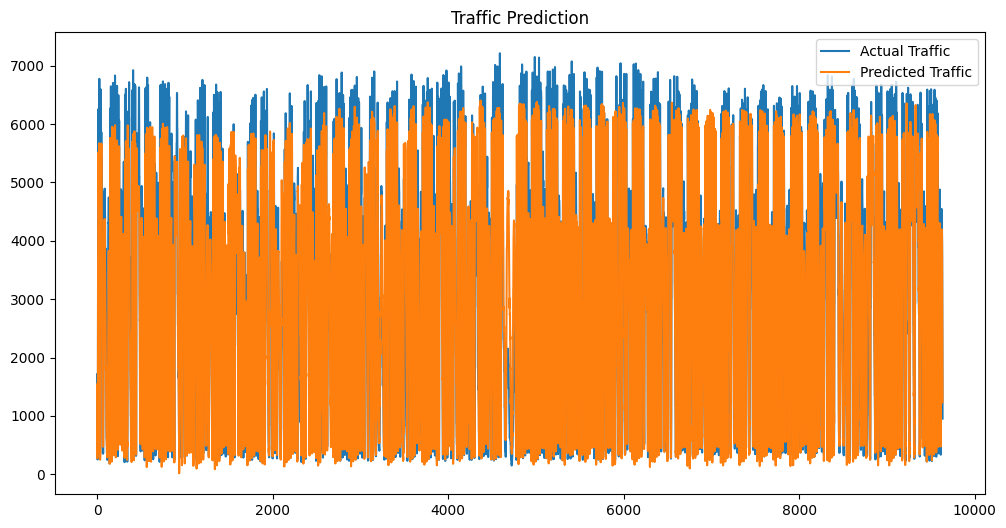

In [27]:
plt.figure(figsize=(12,6))

plt.plot(y_actual, label="Actual Traffic")
plt.plot(predictions, label="Predicted Traffic")

plt.legend()

plt.title("Traffic Prediction")

plt.show()

In [28]:
def traffic_level(v):

    if v < 2000:
        return "LOW"

    elif v < 5000:
        return "MEDIUM"

    else:
        return "HIGH"

In [30]:
error = np.abs(predictions - y_actual)

confidence = 1 - (error / y_actual)

confidence = np.clip(confidence,0,1)

In [32]:
model.save('traffic_model.keras')

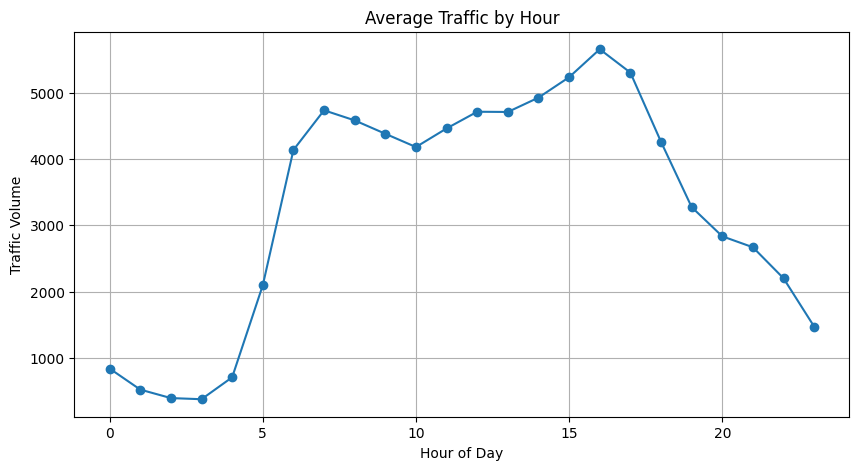

In [34]:
rush_hour = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10,5))

plt.plot(rush_hour.index, rush_hour.values, marker='o')

plt.title("Average Traffic by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Traffic Volume")

plt.grid()

plt.show()

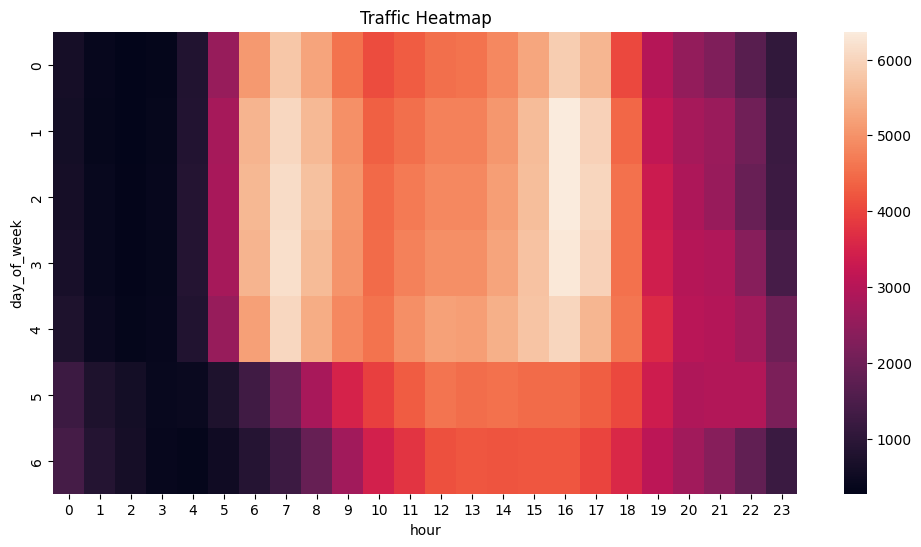

In [35]:
import seaborn as sns

heatmap_data = df.pivot_table(
    values='traffic_volume',
    index='day_of_week',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(heatmap_data)

plt.title("Traffic Heatmap")

plt.show()

In [36]:
df['traffic_level'] = df['traffic_volume'].apply(traffic_level)

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,hour,day_of_week,...,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm,traffic_level
0,NaN,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,9,1,...,False,False,False,False,False,False,False,False,False,HIGH
1,NaN,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,10,1,...,False,False,False,False,False,False,False,False,False,MEDIUM
2,NaN,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,11,1,...,False,False,False,False,False,False,False,False,False,MEDIUM
3,NaN,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,12,1,...,False,False,False,False,False,False,False,False,False,HIGH
4,NaN,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,13,1,...,False,False,False,False,False,False,False,False,False,MEDIUM


In [38]:
level_counts = df['traffic_level'].value_counts(normalize=True)

level_counts

,proportion
traffic_level,
MEDIUM,0.448697
LOW,0.315721
HIGH,0.235582


In [40]:
def congestion_probability(v):

    if v < 2000:
        return 0.30

    elif v < 5000:
        return 0.65

    else:
        return 0.90

In [42]:
predicted_volume = predictions[0][0]

traffic_lvl = traffic_level(predicted_volume)

prob = congestion_probability(predicted_volume)

print("Predicted Traffic:", int(predicted_volume))

print("Traffic Level:", traffic_lvl)

print("Congestion Probability:", int(prob*100),"%")

Predicted Traffic: 1540
Traffic Level: LOW
Congestion Probability: 30 %


In [44]:
output = {

"zone": "Bandra",

"predicted_vehicles": int(predicted_volume),

"traffic_level": traffic_lvl,

"congestion_probability": int(prob*100)

}

output

{'zone': 'Bandra',
 'predicted_vehicles': 1540,
 'traffic_level': 'LOW',
 'congestion_probability': 30}

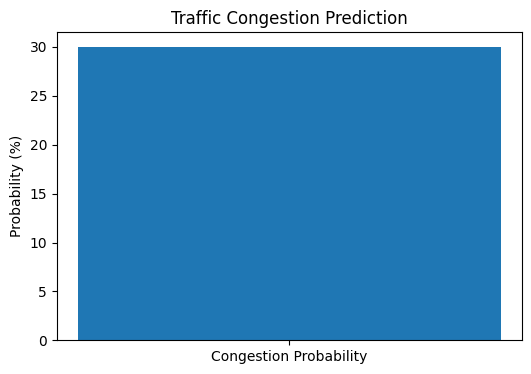

In [45]:
plt.figure(figsize=(6,4))

plt.bar(['Congestion Probability'], [prob*100])

plt.ylabel("Probability (%)")

plt.title("Traffic Congestion Prediction")

plt.show()